<a href="https://colab.research.google.com/github/Sashanka2001/Image_Facial_Landmark_Extraction_Colab/blob/main/04_Facial_landmark_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1: CONNECT GOOGLE DRIVE

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully.")

Mounted at /content/drive
✓ Google Drive mounted successfully.


In [2]:
# CELL 2: DEFINE PROJECT PATHS

import os

# Main research project folder
DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"

# Folder containing your degraded images
DEGRADED_DIR = os.path.join(
    DRIVE_PROJECT,
    "dataset/degraded"
)

print("Project folder:")
print(DRIVE_PROJECT)

print("\nDegraded image folder:")
print(DEGRADED_DIR)

# Check whether the degraded image folder exists
if os.path.exists(DEGRADED_DIR):
    print("\n✓ Degraded image folder exists.")
else:
    print("\n✗ Degraded image folder was NOT found.")
    print("Please check the folder path.")

Project folder:
/content/drive/MyDrive/pre_enhancement_facial_recoverability

Degraded image folder:
/content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded

✓ Degraded image folder exists.


In [3]:
# CELL 3: INSTALL MEDIAPIPE


!pip install -q mediapipe

print("✓ MediaPipe installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.6 MB/s eta 0:00:00
✓ MediaPipe installed.


In [4]:
# CELL 4: IMPORT LIBRARIES
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("✓ Libraries imported successfully.")

MediaPipe version: 1.0.1
✓ Libraries imported successfully.


In [5]:
# CELL 5: DOWNLOAD FACE LANDMARKER MODEL

# Official MediaPipe Face Landmarker model
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/1/"
    "face_landmarker.task"
)

# Where the model will be stored in Colab
MODEL_PATH = "/content/face_landmarker.task"

# Download the model
!wget -q -O /content/face_landmarker.task "$MODEL_URL"

# Check whether download was successful
if os.path.exists(MODEL_PATH):

    print("✓ Face Landmarker model downloaded.")
    print("Model:", MODEL_PATH)

else:

    print("✗ Model download failed.")

✓ Face Landmarker model downloaded.
Model: /content/face_landmarker.task


In [6]:
# CELL 6: CREATE MEDIAPIPE FACE LANDMARKER

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ------------------------------------------------------------
# Define the pretrained model
# ------------------------------------------------------------

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

# ------------------------------------------------------------
# Configure Face Landmarker
# ------------------------------------------------------------

options = vision.FaceLandmarkerOptions(

    base_options=base_options,

    # We are processing individual images
    running_mode=vision.RunningMode.IMAGE,

    # We only expect one face in each cropped face image
    num_faces=1,

    # Detection confidence
    min_face_detection_confidence=0.5,

    # Face presence confidence
    min_face_presence_confidence=0.5,

    # Tracking confidence
    min_tracking_confidence=0.5
)

# ------------------------------------------------------------
# Create the Face Landmarker
# ------------------------------------------------------------

landmarker = vision.FaceLandmarker.create_from_options(
    options
)

print("✓ MediaPipe Face Landmarker is ready.")

✓ MediaPipe Face Landmarker is ready.


In [7]:
# CELL 7: FIND IMAGE FILES

# Supported image formats
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

# List to store image paths
all_images = []

# Search through all subfolders
for root, dirs, files in os.walk(DEGRADED_DIR):

    for file in files:

        # Check whether the file is an image
        if file.lower().endswith(IMAGE_EXTENSIONS):

            full_path = os.path.join(
                root,
                file
            )

            all_images.append(full_path)

# Sort the list so the selection is reproducible
all_images.sort()

print("Total images found:", len(all_images))

Total images found: 56000


In [36]:
# CELL 8: SELECT THREE TEST IMAGES

# Select the first 3 images
test_images = all_images[:10]

print("Selected images for testing:\n")

for i, image_path in enumerate(test_images, start=1):

    print(f"{i}. {image_path}")

Selected images for testing:

1. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded/blur/face_0001_bgr_blur_s1.png
2. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded/blur/face_0001_bgr_blur_s2.png
3. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded/blur/face_0001_bgr_blur_s3.png
4. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded/blur/face_0001_bgr_blur_s5.png
5. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded/blur/face_0001_bgr_blur_s7.png
6. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded/blur/face_0002_bgr_blur_s1.png
7. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded/blur/face_0002_bgr_blur_s2.png
8. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded/blur/face_0002_bgr_blur_s3.png
9. /content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/de

In [37]:
# CELL 9: FUNCTION TO DETECT FACIAL LANDMARKS

def detect_face_landmarks(image_path):
    """
    Detect facial landmarks in one image using MediaPipe.

    Returns:
        image_rgb       - RGB image
        result          - MediaPipe detection result
        face_detected   - True/False
        landmark_count  - number of landmarks
    """

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    image_bgr = cv2.imread(image_path)

    # Check whether image was successfully loaded
    if image_bgr is None:

        print("✗ Could not read:", image_path)

        return None, None, False, 0

    # --------------------------------------------------------
    # Convert BGR → RGB
    # --------------------------------------------------------

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # Convert image to MediaPipe format
    # --------------------------------------------------------

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    # --------------------------------------------------------
    # Run MediaPipe Face Landmarker
    # --------------------------------------------------------

    result = landmarker.detect(mp_image)

    # --------------------------------------------------------
    # Check whether a face was detected
    # --------------------------------------------------------

    number_of_faces = len(
        result.face_landmarks
    )

    if number_of_faces > 0:

        # Get landmarks of first face
        landmarks = result.face_landmarks[0]

        # Count landmarks
        landmark_count = len(landmarks)

        face_detected = True

    else:

        # No face detected
        landmark_count = 0

        face_detected = False

    return (
        image_rgb,
        result,
        face_detected,
        landmark_count
    )

In [38]:
# CELL 10: TEST THE THREE IMAGES

# Store results
test_results = []

# Process each of the 3 images
for image_number, image_path in enumerate(
    test_images,
    start=1
):

    print("\n" + "=" * 70)

    print(f"IMAGE {image_number}")

    print("=" * 70)

    print("Filename:")
    print(os.path.basename(image_path))

    # Detect landmarks
    image_rgb, result, face_detected, landmark_count = (
        detect_face_landmarks(image_path)
    )

    # --------------------------------------------------------
    # Display detection result
    # --------------------------------------------------------

    if face_detected:

        print("FACE DETECTED")
        print("Number of landmarks:", landmark_count)

    else:

        print("NO FACE DETECTED")
        print("Number of landmarks: 0")

    # --------------------------------------------------------
    # Save result information
    # --------------------------------------------------------

    test_results.append({

        "image_number": image_number,

        "filename": os.path.basename(
            image_path
        ),

        "full_path": image_path,

        "face_detected": face_detected,

        "landmark_count": landmark_count
    })


IMAGE 1
Filename:
face_0001_bgr_blur_s1.png
FACE DETECTED
Number of landmarks: 478

IMAGE 2
Filename:
face_0001_bgr_blur_s2.png
FACE DETECTED
Number of landmarks: 478

IMAGE 3
Filename:
face_0001_bgr_blur_s3.png
FACE DETECTED
Number of landmarks: 478

IMAGE 4
Filename:
face_0001_bgr_blur_s5.png
FACE DETECTED
Number of landmarks: 478

IMAGE 5
Filename:
face_0001_bgr_blur_s7.png
FACE DETECTED
Number of landmarks: 478

IMAGE 6
Filename:
face_0002_bgr_blur_s1.png
FACE DETECTED
Number of landmarks: 478

IMAGE 7
Filename:
face_0002_bgr_blur_s2.png
FACE DETECTED
Number of landmarks: 478

IMAGE 8
Filename:
face_0002_bgr_blur_s3.png
FACE DETECTED
Number of landmarks: 478

IMAGE 9
Filename:
face_0002_bgr_blur_s5.png
FACE DETECTED
Number of landmarks: 478

IMAGE 10
Filename:
face_0002_bgr_blur_s7.png
FACE DETECTED
Number of landmarks: 478


In [39]:
# CELL 11: DISPLAY DETECTION RESULTS
results_df = pd.DataFrame(test_results)

display(results_df)

,image_number,filename,full_path,face_detected,landmark_count
0,1,face_0001_bgr_blur_s1.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
1,2,face_0001_bgr_blur_s2.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
2,3,face_0001_bgr_blur_s3.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
3,4,face_0001_bgr_blur_s5.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
4,5,face_0001_bgr_blur_s7.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
5,6,face_0002_bgr_blur_s1.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
6,7,face_0002_bgr_blur_s2.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
7,8,face_0002_bgr_blur_s3.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
8,9,face_0002_bgr_blur_s5.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478
9,10,face_0002_bgr_blur_s7.png,/content/drive/MyDrive/pre_enhancement_facial_...,True,478


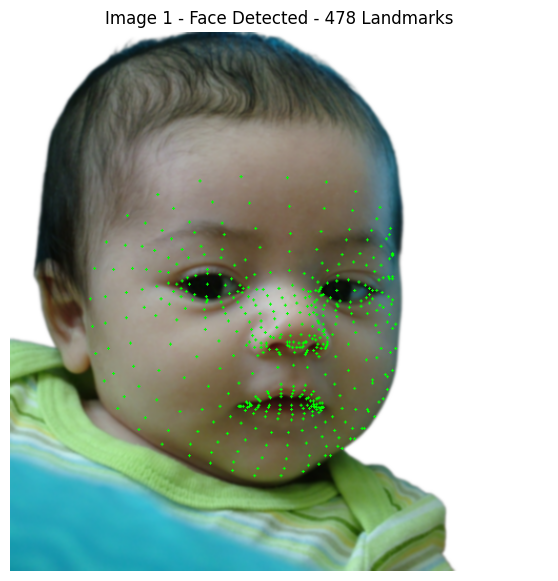

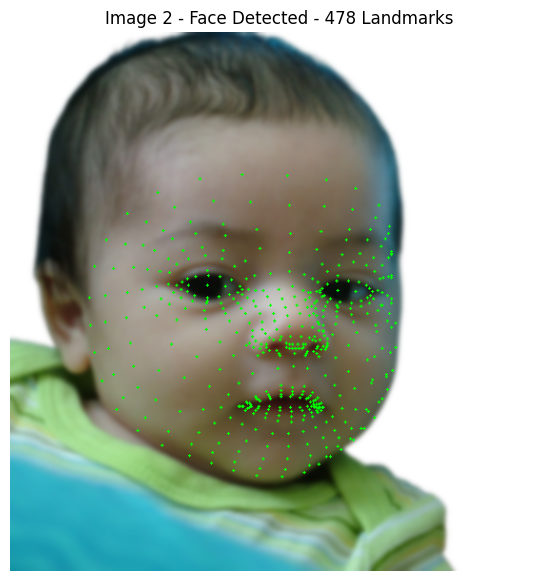

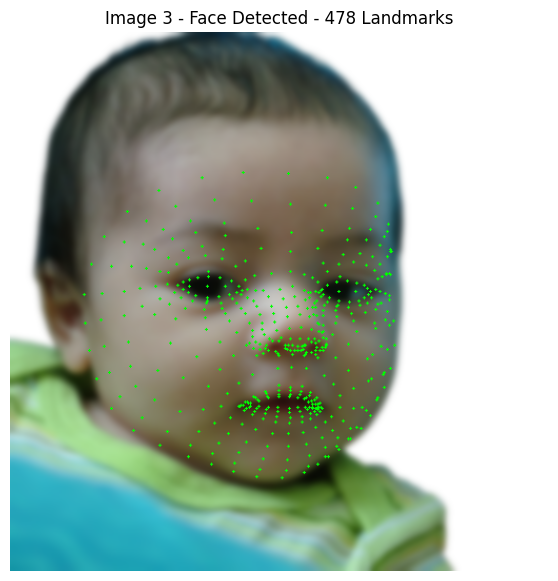

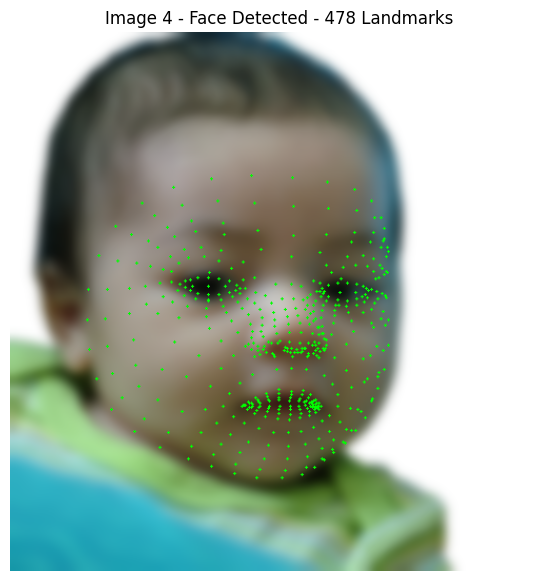

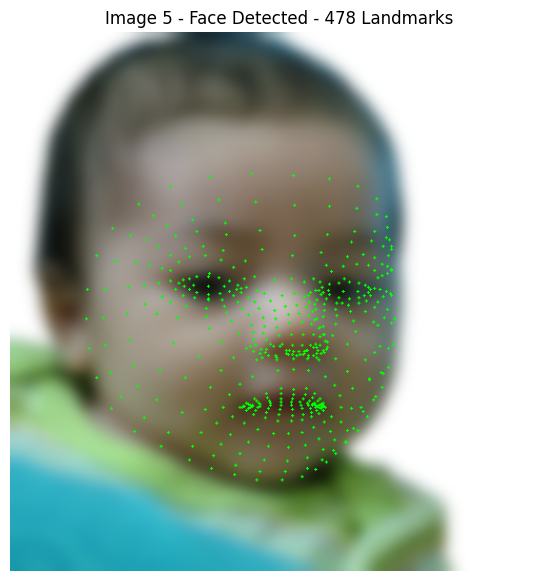

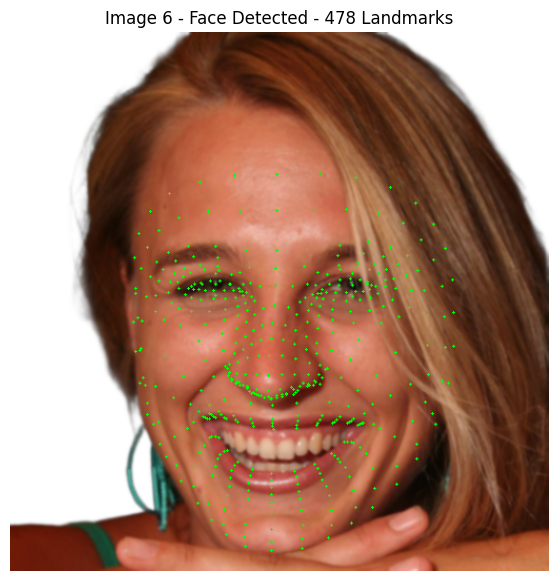

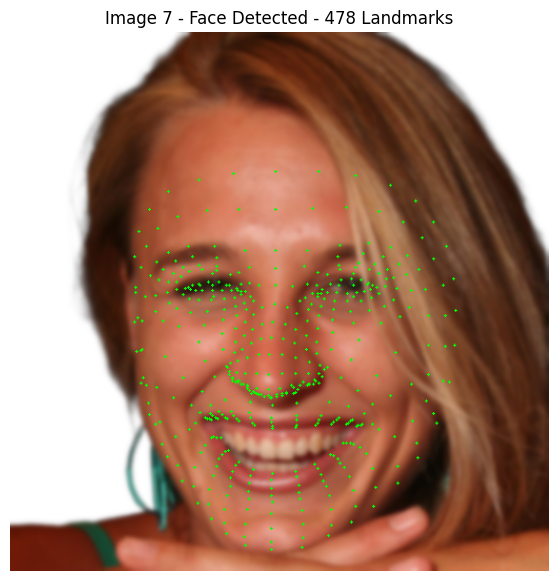

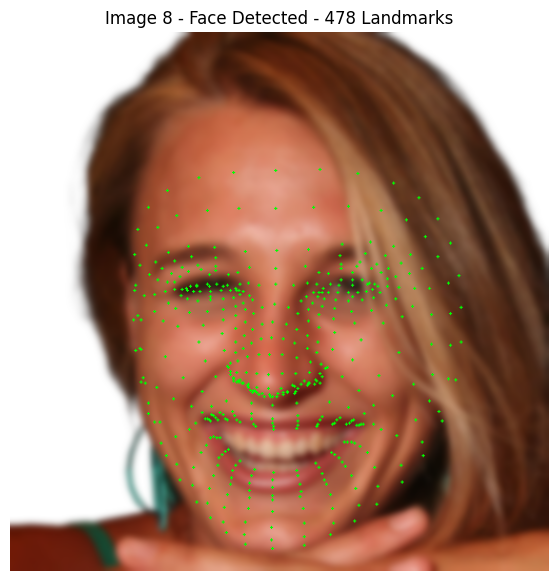

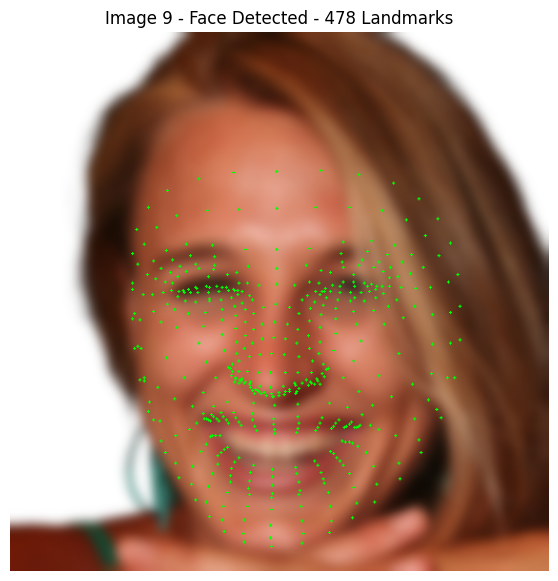

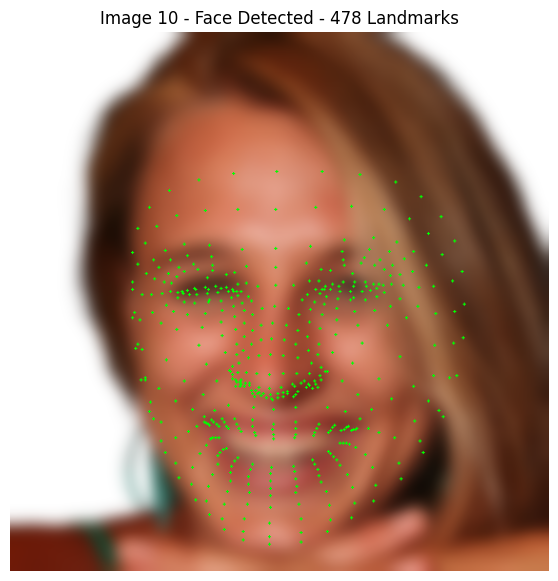

In [40]:
# CELL 12: DRAW LANDMARKS FOR VISUAL INSPECTION

for image_number, image_path in enumerate(
    test_images,
    start=1
):

    # Detect landmarks
    image_rgb, result, face_detected, landmark_count = (
        detect_face_landmarks(image_path)
    )

    # Make a copy of the original image
    annotated_image = image_rgb.copy()

    # --------------------------------------------------------
    # If a face was detected, draw the landmarks
    # --------------------------------------------------------

    if face_detected:

        # Get first detected face
        face_landmarks = result.face_landmarks[0]

        # Get image dimensions
        height, width, _ = annotated_image.shape

        # Draw each landmark
        for landmark in face_landmarks:

            # Convert normalized coordinates
            # into image pixel coordinates
            x = int(
                landmark.x * width
            )

            y = int(
                landmark.y * height
            )

            # Make sure point is inside image
            if (
                0 <= x < width
                and
                0 <= y < height
            ):

                cv2.circle(
                    annotated_image,

                    # Landmark location
                    (x, y),

                    # Dot size
                    1,

                    # Green dot
                    (0, 255, 0),

                    # Filled circle
                    -1
                )

    # --------------------------------------------------------
    # Display image
    # --------------------------------------------------------

    plt.figure(figsize=(7, 7))

    plt.imshow(annotated_image)

    if face_detected:

        plt.title(
            f"Image {image_number} - "
            f"Face Detected - "
            f"{landmark_count} Landmarks"
        )

    else:

        plt.title(
            f"Image {image_number} - "
            f"NO FACE DETECTED"
        )

    plt.axis("off")

    plt.show()

In [42]:
# CELL 13: EXTRACT ALL LANDMARK COORDINATES

# This list will store one row for each image
landmark_coordinate_results = []

# Process the same 3 test images
for image_number, image_path in enumerate(test_images, start=1):

    # Run MediaPipe detection
    image_rgb, result, face_detected, landmark_count = (
        detect_face_landmarks(image_path)
    )

    # Start one row for this image
    row = {
        "image_number": image_number,
        "filename": os.path.basename(image_path),
        "full_path": image_path,
        "face_detected": int(face_detected),
        "landmark_count": landmark_count
    }

    # --------------------------------------------------------
    # If a face was detected
    # --------------------------------------------------------

    if face_detected:

        # Get the landmarks for the first detected face
        face_landmarks = result.face_landmarks[0]

        # Save X, Y, Z for every landmark
        for landmark_index, landmark in enumerate(face_landmarks):

            row[f"landmark_{landmark_index}_x"] = landmark.x
            row[f"landmark_{landmark_index}_y"] = landmark.y
            row[f"landmark_{landmark_index}_z"] = landmark.z

    # --------------------------------------------------------
    # If NO face was detected
    # --------------------------------------------------------

    else:

        # There are no landmark coordinates.
        # Store NaN instead of 0.
        for landmark_index in range(478):

            row[f"landmark_{landmark_index}_x"] = np.nan
            row[f"landmark_{landmark_index}_y"] = np.nan
            row[f"landmark_{landmark_index}_z"] = np.nan

    # Add this image's row to the results
    landmark_coordinate_results.append(row)


print("Landmark coordinate extraction completed.")

Landmark coordinate extraction completed.


In [43]:
# CELL 14: CREATE LANDMARK COORDINATE TABLE

# Convert the list of dictionaries into a DataFrame
landmark_coordinates_df = pd.DataFrame(
    landmark_coordinate_results
)

# Display the table
display(landmark_coordinates_df)

,image_number,filename,full_path,face_detected,landmark_count,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,...,landmark_474_z,landmark_475_x,landmark_475_y,landmark_475_z,landmark_476_x,landmark_476_y,landmark_476_z,landmark_477_x,landmark_477_y,landmark_477_z
0,1,face_0001_bgr_blur_s1.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.526322,0.657208,-0.080446,0.539945,0.562257,...,-0.002121,0.608639,0.451763,-0.002120,0.574615,0.477598,-0.002145,0.605539,0.505638,-0.002140
1,2,face_0001_bgr_blur_s2.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.525255,0.659203,-0.080120,0.539744,0.565454,...,0.000041,0.609264,0.452399,0.000042,0.575006,0.478928,0.000016,0.606209,0.507255,0.000021
2,3,face_0001_bgr_blur_s3.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.521207,0.658408,-0.077923,0.538605,0.568555,...,0.054515,0.611462,0.454086,0.054516,0.578101,0.479695,0.054489,0.607950,0.506707,0.054494
3,4,face_0001_bgr_blur_s5.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.522207,0.666543,-0.074803,0.538368,0.576435,...,0.067192,0.613800,0.457995,0.067192,0.583223,0.481598,0.067164,0.610181,0.506085,0.067169
4,5,face_0001_bgr_blur_s7.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.527182,0.663711,-0.072428,0.542351,0.580305,...,0.041172,0.619716,0.458259,0.041173,0.590750,0.480308,0.041145,0.616422,0.503267,0.041148
5,6,face_0002_bgr_blur_s1.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.486743,0.717371,-0.060647,0.478928,0.664744,...,0.002154,0.635875,0.447493,0.002153,0.609846,0.470290,0.002127,0.636528,0.491343,0.002129
6,7,face_0002_bgr_blur_s2.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.486138,0.716204,-0.058649,0.479261,0.662357,...,-0.000668,0.637316,0.447344,-0.000669,0.611060,0.470288,-0.000696,0.637934,0.491480,-0.000694
7,8,face_0002_bgr_blur_s3.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.487815,0.717157,-0.055833,0.479877,0.661098,...,-0.001688,0.635883,0.447264,-0.001689,0.609549,0.470057,-0.001716,0.636100,0.491246,-0.001714
8,9,face_0002_bgr_blur_s5.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.489875,0.717614,-0.052071,0.484147,0.658314,...,-0.004059,0.638581,0.449921,-0.004059,0.612898,0.472122,-0.004087,0.638798,0.493398,-0.004085
9,10,face_0002_bgr_blur_s7.png,/content/drive/MyDrive/pre_enhancement_facial_...,1,478,0.488313,0.728367,-0.048307,0.481794,0.660263,...,-0.011954,0.636667,0.449057,-0.011954,0.611196,0.471685,-0.011980,0.636995,0.493620,-0.011980


In [44]:
# CELL 15: CHECK TABLE SIZE

print("Number of images:", len(landmark_coordinates_df))

print("Number of columns:", len(landmark_coordinates_df.columns))

print("\nExpected coordinate columns:")
print("478 landmarks × 3 coordinates = 1,434")

print("\nActual coordinate columns:")

coordinate_columns = [
    column
    for column in landmark_coordinates_df.columns
    if column.startswith("landmark_")
]

print(len(coordinate_columns))

Number of images: 10
Number of columns: 1439

Expected coordinate columns:
478 landmarks × 3 coordinates = 1,434

Actual coordinate columns:
1435


In [45]:
# CELL 16: DISPLAY BASIC INFORMATION + FIRST LANDMARKS

# Select basic information columns
basic_columns = [
    "image_number",
    "filename",
    "face_detected",
    "landmark_count"
]

# Add the first 5 landmarks for easy checking
first_landmark_columns = []

for i in range(5):

    first_landmark_columns.extend([
        f"landmark_{i}_x",
        f"landmark_{i}_y",
        f"landmark_{i}_z"
    ])

# Display a smaller part of the table
display(
    landmark_coordinates_df[
        basic_columns + first_landmark_columns
    ]
)

,image_number,filename,face_detected,landmark_count,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,landmark_2_z,landmark_3_x,landmark_3_y,landmark_3_z,landmark_4_x,landmark_4_y,landmark_4_z
0,1,face_0001_bgr_blur_s1.png,1,478,0.526322,0.657208,-0.080446,0.539945,0.562257,-0.122659,0.528049,0.594920,-0.068463,0.510914,0.507487,-0.091390,0.541351,0.541999,-0.128578
1,2,face_0001_bgr_blur_s2.png,1,478,0.525255,0.659203,-0.080120,0.539744,0.565454,-0.123102,0.527404,0.596968,-0.068556,0.511693,0.510031,-0.092649,0.541294,0.545187,-0.129172
2,3,face_0001_bgr_blur_s3.png,1,478,0.521207,0.658408,-0.077923,0.538605,0.568555,-0.121232,0.524791,0.599349,-0.067164,0.512252,0.511646,-0.092360,0.540614,0.548121,-0.127414
3,4,face_0001_bgr_blur_s5.png,1,478,0.522207,0.666543,-0.074803,0.538368,0.576435,-0.118131,0.523459,0.601660,-0.064833,0.513696,0.528358,-0.091028,0.540845,0.558514,-0.124312
4,5,face_0001_bgr_blur_s7.png,1,478,0.527182,0.663711,-0.072428,0.542351,0.580305,-0.118825,0.527028,0.606299,-0.064034,0.516160,0.524806,-0.093128,0.544803,0.560605,-0.125696
5,6,face_0002_bgr_blur_s1.png,1,478,0.486743,0.717371,-0.060647,0.478928,0.664744,-0.144383,0.485853,0.680200,-0.079055,0.465997,0.571131,-0.114576,0.479150,0.637542,-0.153757
6,7,face_0002_bgr_blur_s2.png,1,478,0.486138,0.716204,-0.058649,0.479261,0.662357,-0.142767,0.486178,0.678445,-0.076829,0.465532,0.569805,-0.114455,0.479368,0.635406,-0.152574
7,8,face_0002_bgr_blur_s3.png,1,478,0.487815,0.717157,-0.055833,0.479877,0.661098,-0.140504,0.487260,0.677605,-0.073974,0.465444,0.569568,-0.114475,0.479809,0.634809,-0.151025
8,9,face_0002_bgr_blur_s5.png,1,478,0.489875,0.717614,-0.052071,0.484147,0.658314,-0.138416,0.490018,0.677394,-0.070519,0.467807,0.569232,-0.115545,0.484169,0.632787,-0.150179
9,10,face_0002_bgr_blur_s7.png,1,478,0.488313,0.728367,-0.048307,0.481794,0.660263,-0.135985,0.487991,0.682446,-0.066941,0.465202,0.571867,-0.115495,0.481534,0.634893,-0.148593


In [46]:
# CELL 17: SAVE TEST LANDMARK CSV

# Create a folder for landmark results
LANDMARK_DIR = os.path.join(
    DRIVE_PROJECT,
    "dataset/metadata"
)

os.makedirs(
    LANDMARK_DIR,
    exist_ok=True
)

# Output CSV path
TEST_LANDMARK_CSV = os.path.join(
    LANDMARK_DIR,
    "landmark_coordinates.csv"
)

# Save the table
landmark_coordinates_df.to_csv(
    TEST_LANDMARK_CSV,
    index=False
)

print("CSV saved successfully.")
print(TEST_LANDMARK_CSV)

CSV saved successfully.
/content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/metadata/landmark_coordinates.csv


In [47]:
# CELL 18: VERIFY SAVED CSV

# Read the CSV again
check_df = pd.read_csv(
    TEST_LANDMARK_CSV
)

print("CSV loaded successfully.")

print("\nRows:", check_df.shape[0])
print("Columns:", check_df.shape[1])

print("\nFirst few columns:")
print(check_df.columns[:15].tolist())

CSV loaded successfully.

Rows: 10
Columns: 1439

First few columns:
['image_number', 'filename', 'full_path', 'face_detected', 'landmark_count', 'landmark_0_x', 'landmark_0_y', 'landmark_0_z', 'landmark_1_x', 'landmark_1_y', 'landmark_1_z', 'landmark_2_x', 'landmark_2_y', 'landmark_2_z', 'landmark_3_x']
